# Chicago Risk District Classification
In previous notebooks, we have established that clustering is justified. Our EDA supports a clustering algorithm from multiple perspectives:

1. Temporal analysis - districts exhibit persistent behavior
2. Spatial analysis - significant spatial autocorrelation with Moran's I $=$ 0.431 and its $p$-value of 0.004
3. LISA - well-defined hotspots and coldspots
4. Hopkins statistic - moderate cluster tendency among districts ($H \approx$ 0.64) with very strong structure in the temporal dataset

Now it is time to ask a different question: **how many district profiles exist, and what characterizes each one?** This shifts the focus from *does clustering make sense?* to *what is the best clustering solution?*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from joblib import dump, load

In [2]:
from sys import path

path.insert(0, '../modules')

import utils as f
import params_cfg as pc
import visuals

colors = pc.COLORS
gen_theft = pc.GENERAL_THFT
gen_aslt = pc.GENERAL_ASLT
census_data = pc.CENSUS_DATA

%load_ext autoreload
%autoreload 2

In [3]:
# defining the project paths
brz_path = pc.BRZ_PATH
slv_path = pc.SLV_PATH
gld_path = pc.GLD_PATH
img_path = pc.IMG_PATH
model_path = pc.MODEL_PATH

## Modeling: ASLT
In this section we apply the *K-Means* Machine Learning algorithm to perform a cluster analysis on the districts below. Our goal is to assign districts into well-defined clusters, such that we may recognize similar patterns between districts, realocate resources and apply appropriate countermeasures on each. We shall limit our analysis to $k=5$ clusters maximum.

As a first step, we will remove the outliers and variables with Spearman correlation greater than 0.80. As a second step, it is worth mentioning that we will train the clustering algorithm on the entire training dataset, since we have

- thousands of observations
- more stable estimates of centroids
- and each district has been observed under many conditions (weekdays, weekends, holidays, winter...)

but the predict method will be applied only to the latest features, for the object being clustered is the district, not district-days. That is to say, once the centroids are learned in training, we take the latest features and assign each district to the nearest centroid. We can think of it as customer segmentation where the model is trained on every purchase ever made, to learn customer archetypes, then it is classified on today's customer.

In [4]:
train_aslt = pd.read_csv(
    f'{gld_path}/train_aslt.csv',
    index_col='ddate',
    parse_dates=True,
    dtype={
        'district': str
    }
)

# features to train K-Means
features_aslt = train_aslt\
    .drop(columns=['district'])\
    .dropna()\
    .reset_index(drop=True)\
    .copy()

# features to predict
latest_features = train_aslt\
    .groupby('district')\
    .tail(1)\
    .drop(columns=['district'])\
    .reset_index(drop=True)\
    .copy()

# removing outliers
features_aslt = f.rm_outliers(features_aslt, s=3)

features_aslt.head()

N. of outliers: 1801 (5.634%)


,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgDist7,ASLT_RollAvgMaxDist7,ASLT_RollAvgCMLen7,ASLT_RollAvgLen7,ASLT_RollAvgHardship7,ASLT_RollAvgCountCMArea7,ASLT_RollAvgDRateCMArea7,ASLT_RollAvgARateCMArea7,ASLT_RollAvgDensity7
0,5.285714,0.293651,0.214286,1.713848,35.387097,37.256894,186.284470,41.198413,0.077781,0.004321,0.003153,0.015556
1,6.857143,0.335793,0.146507,2.484215,21.287635,43.799069,437.990695,33.493734,0.087821,0.004301,0.001876,0.008782
2,5.571429,0.404422,0.236395,2.754716,32.274564,48.763518,390.108148,38.385034,0.055021,0.003994,0.002335,0.006878
3,12.428571,0.397576,0.187977,1.698811,25.040365,44.442936,311.100550,87.822477,0.129360,0.004138,0.001957,0.018480
4,14.857143,0.510369,0.093152,2.142886,28.451400,42.850458,514.205491,65.981803,0.172809,0.005936,0.001083,0.014401


In [ ]:
# Spearman measures monotonic relationship, whereas
# Perason measures strictly linear
features_aslt.corr(method='spearman')

,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgDist7,ASLT_RollAvgMaxDist7,ASLT_RollAvgCMLen7,ASLT_RollAvgLen7,ASLT_RollAvgHardship7,ASLT_RollAvgCountCMArea7,ASLT_RollAvgDRateCMArea7,ASLT_RollAvgARateCMArea7,ASLT_RollAvgDensity7
ASLT_RollAvg7,1.000000,0.312039,0.097387,0.169154,-0.387906,0.015292,0.237087,0.621488,0.857914,0.176570,0.015797,0.638479
ASLT_RollDRate7,0.312039,1.000000,-0.062633,0.269723,0.206844,-0.006961,0.278831,0.587312,0.198485,0.815437,-0.156738,0.014106
ASLT_RollARate7,0.097387,-0.062633,1.000000,-0.199302,-0.230184,0.264586,-0.120221,0.161457,-0.052841,-0.231937,0.791485,0.125525
ASLT_RollAvgDist7,0.169154,0.269723,-0.199302,1.000000,0.224099,0.006086,0.658221,0.109488,0.171814,0.249553,-0.190945,-0.335156
ASLT_RollAvgMaxDist7,-0.387906,0.206844,-0.230184,0.224099,1.000000,0.058746,0.110737,-0.221079,-0.429942,0.175271,-0.282598,-0.412482
ASLT_RollAvgCMLen7,0.015292,-0.006961,0.264586,0.006086,0.058746,1.000000,0.254128,0.024569,-0.403279,-0.501548,-0.264323,-0.289862
ASLT_RollAvgLen7,0.237087,0.278831,-0.120221,0.658221,0.110737,0.254128,1.000000,0.314122,0.077088,0.101119,-0.323068,-0.521214
ASLT_RollAvgHardship7,0.621488,0.587312,0.161457,0.109488,-0.221079,0.024569,0.314122,1.000000,0.401347,0.377326,-0.028613,0.225698
ASLT_RollAvgCountCMArea7,0.857914,0.198485,-0.052841,0.171814,-0.429942,-0.403279,0.077088,0.401347,1.000000,0.336467,0.170842,0.746772
ASLT_RollAvgDRateCMArea7,0.176570,0.815437,-0.231937,0.249553,0.175271,-0.501548,0.101119,0.377326,0.336467,1.000000,0.008900,0.120913


In [6]:
features_aslt = features_aslt.drop(
    columns=[
        'ASLT_RollAvgCountCMArea7',
        'ASLT_RollAvgDRateCMArea7',
        'ASLT_RollAvgARateCMArea7'
    ]
)

latest_features = latest_features.drop(
    columns=[
        'ASLT_RollAvgCountCMArea7',
        'ASLT_RollAvgDRateCMArea7',
        'ASLT_RollAvgARateCMArea7'
    ] 
)

### Model Specification

#### Operational Risk

In [21]:
model_risk = [
    'ASLT_RollAvgDensity7',
    'ASLT_RollDRate7',
    'ASLT_RollARate7',
    'ASLT_RollAvgHardship7'
]

output = {}
k_values = range(2, 6)

scaler_aslt = StandardScaler()

X_risk = scaler_aslt.fit_transform(features_aslt[model_risk])
X_latest_risk = scaler_aslt.transform(latest_features[model_risk])

output = f.KMeans_features(X_risk, X_latest_risk, k_values)
pd.DataFrame(output)

Initiating k=2
Initiating k=3
Initiating k=4
Initiating k=5


,sse,silhouettes,ch,db
0,81344.743959,0.293950,9.601034,1.224172
1,64073.850806,0.246420,9.277977,1.222093
2,51940.240782,0.176764,8.864983,1.162547
3,44150.503940,0.209512,9.051653,1.100528


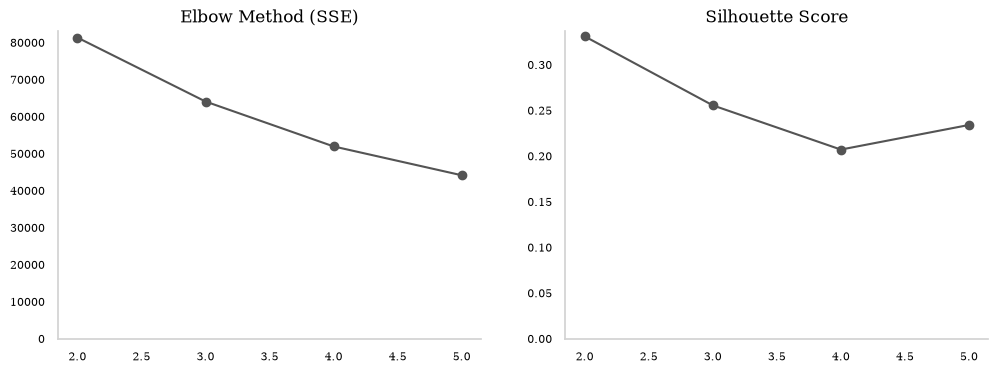

In [9]:
sse = output['sse']
silhouettes = output['silhouettes']
ch = output['ch']
db = output['db']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_values, sse, marker='o', color='#545454')
ax[0].set_title('Elbow Method (SSE)')
ax[0].set_ylim(0)
ax[1].plot(k_values, silhouettes, marker='o', color='#545454')
ax[1].set_ylim(0)
ax[1].set_title('Silhouette Score')

# plt.savefig(f'{img_path}/fig27.png', dpi=300)

plt.show()

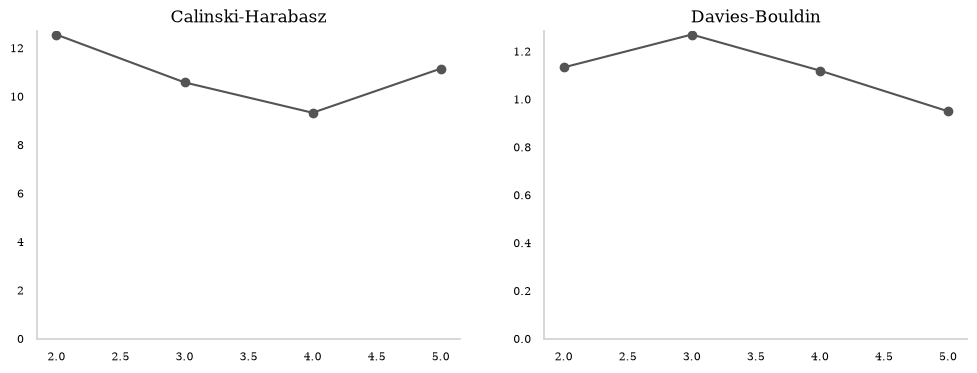

In [11]:
ch = output['ch']
db = output['db']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_values, ch, marker='o', color='#545454')
ax[0].set_title('Calinski-Harabasz')
ax[0].set_ylim(0)
ax[1].plot(k_values, db, marker='o', color='#545454')
ax[1].set_ylim(0)
ax[1].set_title('Davies-Bouldin')

# plt.savefig(f'{img_path}/fig27.png', dpi=300)

plt.show()

In [22]:
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=1, n_init=50)
kmeans.fit(X_risk)

profiles_risk = train_aslt.groupby('district').tail(1).copy()
profiles_risk['cluster'] = kmeans.predict(X_latest_risk)
profiles_risk[model_risk + ['cluster']].groupby('cluster').median()

,ASLT_RollAvgDensity7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgHardship7
cluster,,,,
0,0.010163,0.384938,0.216837,62.839286
1,0.010603,0.194728,0.209981,14.872279
2,0.028459,0.398440,0.331181,73.000000


#### Risk + Accessibility

In [23]:
model_access = model_risk + ['ASLT_RollAvgDist7']

output = {}
k_values = range(2, 6)

scaler_aslt = StandardScaler()

X_access = scaler_aslt.fit_transform(features_aslt[model_access])
X_latest_access = scaler_aslt.transform(latest_features[model_access])

output = f.KMeans_features(X_access, X_latest_access, k_values)
pd.DataFrame(output)

Initiating k=2
Initiating k=3
Initiating k=4
Initiating k=5


,sse,silhouettes,ch,db
0,110550.887870,0.222009,6.239162,1.346837
1,82253.010443,0.241840,7.876401,1.243795
2,73905.305618,0.231062,6.820786,1.080423
3,64674.676880,0.192373,7.796062,1.062564


In [24]:
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=1, n_init=50)
kmeans.fit(X_access)

profiles_access = train_aslt.groupby('district').tail(1).copy()
profiles_access['cluster'] = kmeans.predict(X_latest_access)
profiles_access[model_access + ['cluster']].groupby('cluster').median()

,ASLT_RollAvgDensity7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgHardship7,ASLT_RollAvgDist7
cluster,,,,,
0,0.010034,0.384938,0.296376,62.839286,2.735978
1,0.010603,0.217001,0.168139,14.872279,1.658094
2,0.024640,0.388188,0.296630,73.000000,1.843187


#### Risk + Spatial

In [25]:
model_spatial = model_risk + ['ASLT_RollAvgLen7']

output = {}
k_values = range(2, 6)

scaler_aslt = StandardScaler()

X_spatial = scaler_aslt.fit_transform(features_aslt[model_spatial])
X_latest_spatial = scaler_aslt.fit_transform(latest_features[model_spatial])

output = f.KMeans_features(X_spatial, X_latest_spatial, k_values)
pd.DataFrame(output)

Initiating k=2
Initiating k=3
Initiating k=4
Initiating k=5


,sse,silhouettes,ch,db
0,110937.234089,0.273512,8.068902,1.449909
1,77720.431841,0.270996,9.744148,1.128158
2,70689.538248,0.272451,8.890040,0.901590
3,58374.058186,0.251112,8.966393,0.849001


In [27]:
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=1, n_init=50)
kmeans.fit(X_spatial)

profiles_spatial = train_aslt.groupby('district').tail(1).copy()
profiles_spatial['cluster'] = kmeans.predict(X_latest_spatial)
profiles_spatial[model_spatial + ['cluster']].groupby('cluster').median()

,ASLT_RollAvgDensity7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgHardship7,ASLT_RollAvgLen7
cluster,,,,,
0,0.026550,0.393314,0.313905,78.208977,308.839316
1,0.010034,0.384938,0.296376,62.839286,506.067496
2,0.012434,0.229071,0.167230,20.304762,303.620999


#### Dynamics

In [28]:
model_dyn = [
    'ASLT_RollAvg7',
    'ASLT_RollDRate7',
    'ASLT_RollARate7',
    'ASLT_RollAvgHardship7'
]

output = {}
k_values = range(2, 6)

scaler_aslt = StandardScaler()

X_dyn = scaler_aslt.fit_transform(features_aslt[model_dyn])
X_latest_dyn = scaler_aslt.fit_transform(latest_features[model_dyn])

output = f.KMeans_features(X_dyn, X_latest_dyn, k_values)
pd.DataFrame(output)

Initiating k=2
Initiating k=3
Initiating k=4
Initiating k=5


,sse,silhouettes,ch,db
0,71058.646014,0.366412,15.832624,1.065885
1,58991.307268,0.260277,11.306142,1.197625
2,47074.025946,0.150830,8.832167,1.357261
3,41157.489938,0.166999,9.371701,1.218253


In [29]:
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=1, n_init=50)
kmeans.fit(X_dyn)

profiles_dyn = train_aslt.groupby('district').tail(1).copy()
profiles_dyn['cluster'] = kmeans.predict(X_latest_dyn)
profiles_dyn[model_dyn + ['cluster']].groupby('cluster').median()

,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgHardship7
cluster,,,,
0,11.428571,0.386563,0.209784,64.064650
1,6.714286,0.229071,0.169048,22.072619
2,13.857143,0.425911,0.351333,83.417954


### Forward Feature Selection
From the metrics we notice that they are not optimal, such that some feature selection can be performed. It shall be done with *feature forward selection*, where we:

1. Start with no variables.
2. Test each individually.
3. Keep the one that produces the best clustering.
4. Add one new variable at a time.
5. At each itearation, choose the variable that most improves the clustering metrics.
6. Stop when adding variables no longer improves the solution.

Unlike supervised learning, there is no accuracy, so we optimize using

- greater silhouette
- greater Calinski-Harabasz
- lower Davies-Bouldin

In [53]:
selected, history, detailed = f.fwd_feature_selection(
    features_aslt,
    latest_features,
    candidate_features=list(features_aslt.columns)
)

------------------------------
STEP 1
Added feature: ASLT_RollAvgDensity7
Current set: ['ASLT_RollAvgDensity7']
Mean Silhouette: 0.583
Mean Calinski-Harabasz: 110.605
Mean Davies-Bouldin: 0.458
------------------------------
------------------------------
STEP 2
Added feature: ASLT_RollAvgDist7
Current set: ['ASLT_RollAvgDensity7', 'ASLT_RollAvgDist7']
Mean Silhouette: 0.441
Mean Calinski-Harabasz: 24.042
Mean Davies-Bouldin: 0.715
------------------------------
------------------------------
STEP 3
Added feature: ASLT_RollAvgLen7
Current set: ['ASLT_RollAvgDensity7', 'ASLT_RollAvgDist7', 'ASLT_RollAvgLen7']
Mean Silhouette: 0.397
Mean Calinski-Harabasz: 22.039
Mean Davies-Bouldin: 0.798
------------------------------
------------------------------
STEP 4
Added feature: ASLT_RollDRate7
Current set: ['ASLT_RollAvgDensity7', 'ASLT_RollAvgDist7', 'ASLT_RollAvgLen7', 'ASLT_RollDRate7']
Mean Silhouette: 0.293
Mean Calinski-Harabasz: 12.734
Mean Davies-Bouldin: 1.018
------------------------

### Feature Search

In [10]:
results = f.exhaustive_feature_search(
    features_aslt,
    latest_features,
    candidate_features=list(features_aslt.columns)
)

In [6]:
results = pd.read_csv('results.csv', index_col=0)
results

,features,n_features,best_k,silhouette,calinski,davies,score
0,"('ASLT_RollAvg7', 'ASLT_RollAvgDensity7')",2,3,0.434267,24.056009,0.849875,3.0
1,"('ASLT_RollDRate7', 'ASLT_RollAvgDist7', 'ASLT...",3,2,0.419315,16.928951,0.955690,3.0
2,"('ASLT_RollDRate7', 'ASLT_RollAvgLen7', 'ASLT_...",3,2,0.399717,17.165308,0.966894,3.0
3,"('ASLT_RollAvgCMLen7', 'ASLT_RollAvgLen7', 'AS...",3,2,0.377126,10.904279,1.120053,3.0
4,"('ASLT_RollARate7', 'ASLT_RollAvgCMLen7', 'ASL...",3,2,0.369061,14.683491,1.020904,3.0
...,...,...,...,...,...,...,...
506,"('ASLT_RollAvg7',)",1,4,0.578915,100.143396,0.440678,7.0
507,"('ASLT_RollAvgDist7', 'ASLT_RollAvgCMLen7')",2,2,0.443518,10.852692,0.888232,7.0
508,"('ASLT_RollAvgCMLen7', 'ASLT_RollAvgLen7')",2,3,0.341092,9.388940,0.933394,7.0
509,"('ASLT_RollARate7', 'ASLT_RollAvgDist7', 'ASLT...",5,3,0.257031,7.114788,1.199633,7.0


In [41]:
results.to_csv('results.csv')

### Cluster Interpretation for ASLT
After analysing the resulting clusters for $k \in \{2, 3, 4, 5\}$, we understand as the optimal number $k^\ast=4$, where its clusters can be easily interpreted, such that immediate counter measures may follow. $k^\ast = 3$ is also a viable choice, but we stick to $k^\ast = 4$ for operational richness. For instance, it is natural to distinguish district-level crime patterns as

1. High-violence + high hardship areas
2. Moderate-violence + moderate hardship areas
3. Lower-violence + lower hardship areas

but, given we have domestic and arrest rates, we can include a fourth category to account for public crimes and police effectiveness. Of course, there are several limitations to be considered, such as reporting bias (not all incidents are reported), arrest counts depends on police practices, and hardship index is represented by an older census data. Nonetheless, as first model (MVP) it seems a good place to start.

We can rank them in many ways, so as to give more importance for crime volume or hardship index, for example, but as we are considering more variables into our framework, we choose to rank them in the following manner:

**Cluster 0:** Low Activity Overall and Lowest Hardship Index
- Low assault rate
- Low domestic rate
- Low hardship index
- High arrest
- Profile summary
    - wealthier, well-policed zones, with focus on prevention rather than intervention

**Cluster 1:** Low Volume, but Under-Policed with High Domestic Pressure
- Lowest assault rate
- High domestic rate
- Moderate hardship index
- Profile summary
    - domestic violence prevention is critical, even tough assault rate is low. Community programs and victim support and social services could be more impactful than broad policing

**Cluster 2:** High Assaults in Very High Hardship Areas with Strong Enforcement
- High assault rate
- Highest hardship index
- High domestic rate
- Highest arrest rate: strong law enforcement capacity
- Profile summary
    - most socioeconomically distressed areas, with high assault and domestic frequency, but with relatively strong arrest performance, indicating focused intervention

**Cluster 3:** Extreme Urban Hot Zones
- Highest risk overall (assault rate and domestic rate) with low arrest rate
- High hardship index
- Profile summary
    - needs urgent integrated response, such as socioeconomic support, police intervention and domestic violence prevention; poor arrest rate may indicate enforcement challenges or highly complex cases
    - top priority cluster: represents the city's most intense violence-related vulnerability

We conclude, then, that what define the clusters is their aggresiveness (crime volume and domestic violence), police effectiveness (arrest rates), and their hardship index (poverty level). In addition, we observe that crime volume and hardship correlate strongly and domestic violence is a great divider.

In [14]:
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=1, n_init='auto')

cluster_aslt = train_aslt.dropna().reset_index(drop=True).copy()

scaler_aslt = StandardScaler()
scaler_aslt.fit(features_aslt)
X_aslt = scaler_aslt.transform(features_aslt)

kmeans.fit(X_aslt)

X_aslt = scaler_aslt.transform(cluster_aslt[features_list])

cluster_aslt['cluster'] = [pc.cluster_mapping['ASLT'][x] for x in kmeans.predict(X_aslt)]
# cluster_aslt['cluster'] = kmeans.predict(X_aslt)

cluster_aslt[features_list + ['cluster']]\
    .groupby('cluster')\
    .agg(['median'])

,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgHardship7
,median,median,median,median
cluster,,,,
0,11.285714,0.158856,0.226643,9.614627
1,9.428571,0.272678,0.147388,31.777188
2,16.714286,0.341858,0.243999,82.836887
3,18.000000,0.363745,0.152768,62.996152


We next save our model and scaler for future use.

In [27]:
dump(scaler_aslt, f'{model_path}/scaler_aslt.pkl')
dump(kmeans, f'{model_path}/kmeans_aslt.pkl')

['../../models/kmeans_aslt.pkl']

### Strategic Use for Clusters: ASLT
The profiles can be used mainly to **i)** prioritze resource distribution across districts; **ii)** design tailored community safety programs; **iii)** understand Chicago main risk profile; and **iv)** guide further predictive modelling or risk scoring (model's result can serve as input for another models).

In particular for item **iii)**, if we calculate the district distribution per cluster (next section), we find ~23% in Cluster 3, which is a zone with high crime activity both in the streets and inside the residences. That corrobarates with the high crime volume in all Chicago, where we obtain an average of ~14 occurrences in a 7-day window, which is 2 occurrences per day, yielding almost 1,000 in a year. Therein, we have also ~20% of average arrest rate, roughly saying that most of offenders, 4 out of 5, remain in the open. As for item **i)**, we understand that Cluster 3 deserves special attention, as they represent poorer areas with the highest intensity, where we must ensure continued support for enforcement and investments on social interventions must be prioritized in order to reduce long-term pressure.

In [30]:
print(train_aslt['ASLT_RollAvg7'].mean())
print(train_aslt['ASLT_RollARate7'].mean())

14.433316839651605
0.18688522601676325


### Cluster Distribution
One interest measure to have is the cluster distribution, to assess how crime volume is located in Chicago. To this end, we get the latest date available for each district, which is 2024-12-31, and calculate the percentage cluster distribution for this date.

In [5]:
kmeans_aslt = load(f'{model_path}/kmeans_aslt.pkl')
scaler_aslt = load(f'{model_path}/scaler_aslt.pkl')

In [6]:
cluster_aslt = train_aslt.dropna().reset_index(drop=True).copy()

X_aslt = scaler_aslt.transform(cluster_aslt[features_list])

cluster_aslt['cluster'] = [pc.cluster_mapping['ASLT'][x] for x in kmeans_aslt.predict(X_aslt)]

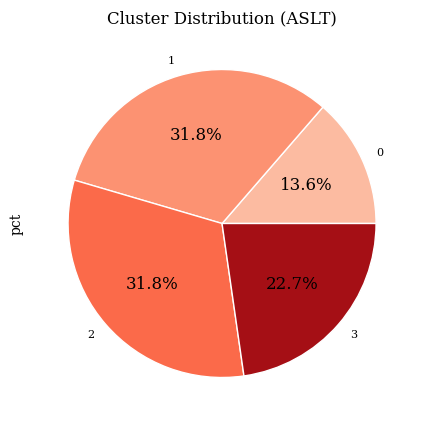

In [10]:
# getting the latest date for each district
date_df = cluster_aslt[['date', 'district']]\
    .groupby('district')\
    .max()\
    .reset_index()

# merging to get only the latest date records and hence the latest clusters
aux = cluster_aslt[['date', 'district', 'cluster']]\
    .merge(
        date_df,
        on=['date', 'district'],
        how='inner'
    )

# calculating the percentage distribution of clusters
aux = aux[['district', 'cluster']]\
    .groupby('cluster')\
    .count() / len(aux)

aux = aux.rename(columns={'district': 'pct'})

aux.plot(
    kind='pie',
    y='pct',
    autopct='%1.1f%%',
    legend=False,
    colors= pc.CLUSTER_COLORS['hex'].values(),
    title='Cluster Distribution (ASLT)'
);

plt.savefig(f'{img_path}/fig28.png', dpi=300)

The distribution above, however, varies over time, since our metrics are dynamic (based on a rolling window). The plot below thus shows its evolvution in time.

In [31]:
daily_dist = (
    cluster_aslt[['district', 'date', 'cluster']]
    .groupby(['date', 'cluster'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .reset_index(level=0, drop=True)
    .to_frame(name='pct')
    .reset_index()
)
daily_dist

,date,cluster,pct
0,2022-01-07,0,0.090909
1,2022-01-07,1,0.363636
2,2022-01-07,2,0.090909
3,2022-01-07,3,0.454545
4,2022-01-08,0,0.045455
...,...,...,...
4354,2024-12-30,3,0.238095
4355,2024-12-31,0,0.136364
4356,2024-12-31,1,0.272727
4357,2024-12-31,2,0.363636


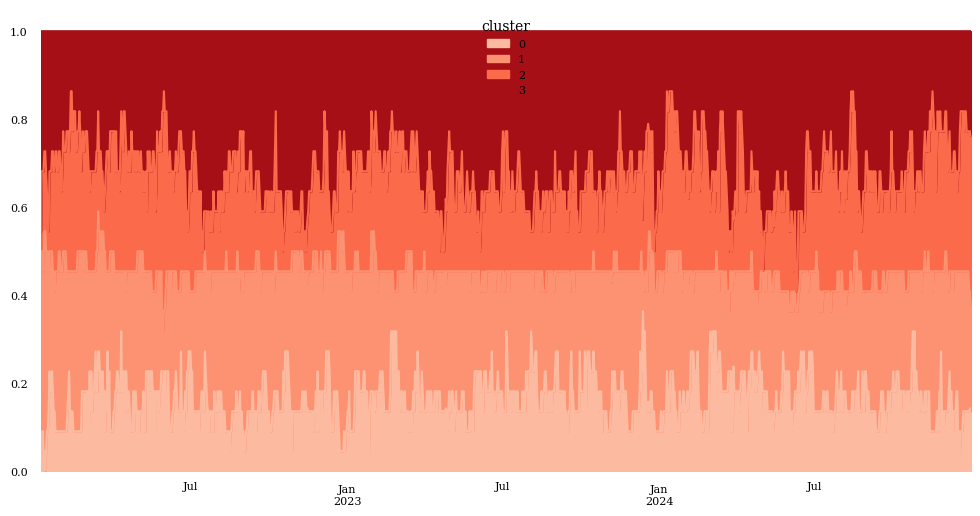

In [50]:
daily_dist.pivot(
    index='date',
    columns='cluster',
    values='pct'
).plot.area(
    color=pc.CLUSTER_COLORS['hex'],
    figsize=(12, 6)
)
plt.xlabel('')
plt.box(False)

We see a prevalence of cluster 3, with nearly 40% of the distribution at some points, indicating that most districts of Chicago is in a high-risk state/cluster. This aligns with real-world [data](https://counciloncj.org/crime-in-chicago-what-you-need-to-know/) showing persistent violent neighborhoods in Chicago.

Later, we will evaluate the transition matrix, where each element represents transition probabilities between clusters, and will find that each cluster is stable enough such that there is a 90% historical probability of a district to remain at cluster 3 once it has reached it, hence reflecting structural inequality.

By choosing a particular district, for illustration, we are able to see how its cluster changes along the way by plotting cluster vs date. We observe that it alternates between clusters 0, 2 and 3, suggesting that we can also consider a measure of cluster volatility to quantify such variations.

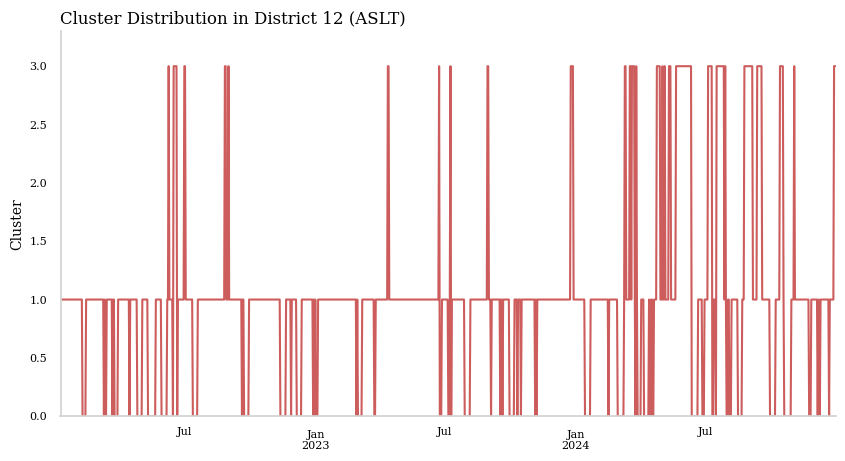

In [31]:
d = '12'
aux = cluster_aslt[['district', 'date', 'cluster']]\
    .query('district == @d')

aux['cluster'] = aux['cluster'].astype(int)

aux.plot(
    x='date',
    y='cluster',
    color='indianred',
    legend=False
)
plt.title(f'Cluster Distribution in District {d} (ASLT)', loc='left')
plt.ylim(0, (k_opt - 1) * 1.1)
plt.ylabel('Cluster')
plt.xlabel('');

plt.savefig(f'{img_path}/fig29.png', dpi=300)

### Cluster Intensity and Volatility
To aid in comparisons among districts, we can define *cluster intensity* and *cluster volatility* as numeric measures to quantify how aggressive a cluster is and how volatile a district is through time, that is, how often it shifts from cluster $m$ to $n$, with $m \neq n$, and how strong is the shift. Moreover, we have seen that $0 \to 1 \to 2 \to 3$ increases in overall crime volume and aggressiveness, such that Cluster 3 is represented by more aggressive districts than Cluster 1. In other words, aggressiveness increases as $n$ increases.

As for the volatility, it is interesting to consider a measure that encompasses the shift strength and frequency. For instance, a district that shifts from $0 \to 1$ must be less volatile than one that shifts from $0 \to 2$ or $0 \to 3$, considering the same time period. We thus seek a measure of the form $$V_{mn} = \frac{1}{\Delta t} \left|{I_n - I_m} \right|,$$ where $I_n$ stands for the $n$-th cluster intensity, which is some monotonic function of $n$, such that it must satisfy $$I_n > I_m, \qquad n > m.$$ The denominator $\Delta t$ represents the time period, in days, under consideration. For convenience, we consider $\Delta t = 7$, to match the 7-day window above.

The cluster intensity can be defined simply as $$I_n \coloneqq \ln (1 + n), \qquad n \in \{0, 1, 2, 3\},$$ since it satisfies all necessary conditions, is a well-behaved function, and $I_0=0$. Thefore, we end up with $$V_{mn} = \frac{1}{7} \left| \frac{\ln(1 + n)}{\ln( 1 + m)} \right|.$$ Obs: one could also consider some linear function $I_n = n$, yielding $V_{mn} = (1/7) |n - m|$, but such function could be problematic in case of eventual integrations.

Below we see its graphic representation through time for some districts.

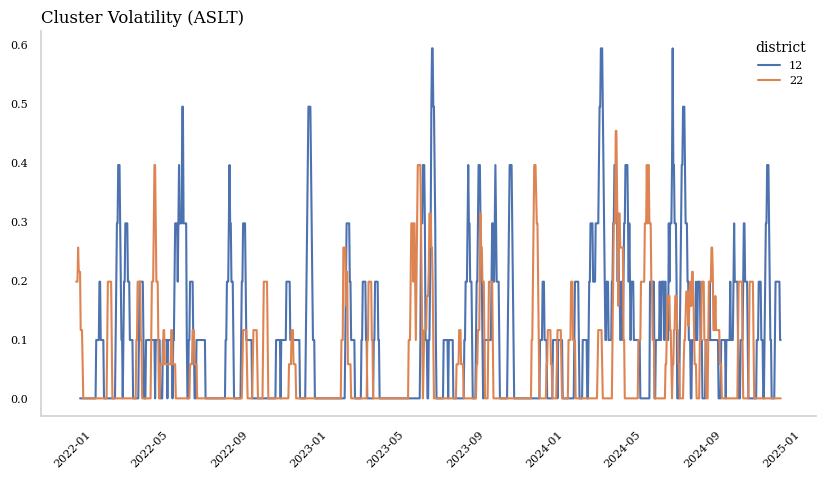

In [33]:
districts = ['12', '22']

aux = cluster_aslt[cluster_aslt['district'].isin(districts)]\
    [['date', 'district', 'cluster']]\
    .copy()


aux['cluster_intensity'] = aux['cluster'].apply(f.cluster_intensity, scale='log')
aux['cluster_vol'] = aux['cluster_intensity']\
    .diff().abs()\
    .fillna(0)\
    .rolling(7).mean()

sns.lineplot(
    data=aux,
    x='date',
    y='cluster_vol',
    hue='district'
)
plt.title('Cluster Volatility (ASLT)', loc='left')
plt.ylabel('')
plt.xticks(rotation=45)
plt.xlabel('');

plt.savefig(f'{img_path}/fig30.png', dpi=300)

## Transition Matrix
A cluster transition matrix is one of the most powerful tools one can use when in possession of a cluster over time dataframe. It gives a single, interpretable view of how districts migrate from one risk profile to another over time. Formally, it is a $k \times k$ matrix, with $k$ the number of clusters, and with elements $T_{mn}$ representing the probability that a district moves from cluster $m$ to cluster $n$.

In [10]:
transition_matrix = f.get_transition_matrix(cluster_aslt)
transition_matrix

next_cluster,0,1,2,3
cluster,,,,
0,0.886323,0.111647,0.001269,0.000761
1,0.063882,0.916327,0.008586,0.011205
2,0.000953,0.010863,0.886030,0.102154
3,0.000634,0.009643,0.068519,0.921203


From the matrix above, we obtain a meanigufl model of violence evolution. Particularly, we note that:
- all clusters are extremely stable on a weekly basis (diagonal values), indicating that
    - the clustering captured true structural patterns and not just random noise
    - interventions needs months, not days, to show effect, which aligns well from what is known from criminology: **i)** social condition, policing, and community factors change slowly; and **ii)** districts rarely jump from safe to high-violence in a short window, showing that the model behaves realistically
- districts in low-risk areas most commonly drift toward cluster 1 and not toward high-violence clusters (row 0), suggesting cluster 1 as a transitional zone
- districts where domestic violence is dominant tend to stay that way, but have some improvement if local enforcenment improves (row 1)
- cluster 2 is an escalation threshold (it is the tipping point) with almost no recovery to low-risk groups (row 2), meaning that cluster 2 requires early intervention before it becomes cluster 3
- once a districts reaches high violence, it almost never goes back down (row 3), thus being a long-term risk condition

## OOT
In this section we evaluate the model in an out-of-time period, much like the testing set. We can perform the same analysis, but comparing them with training period to assess data and model drift.

In [11]:
oot_aslt = pd.read_csv(f'{gld_path}/oot_aslt.csv')
oot_aslt['date'] = pd.to_datetime(oot_aslt['date'])
oot_aslt['district'] = oot_aslt['district'].astype(str)

oot_aslt.head()

,district,date,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgDist7,ASLT_RollAvgMaxDist7,ASLT_RollAvgCMLen7,ASLT_RollAvgLen7,ASLT_RollAvgHardship7,ASLT_RollAvgCountCMArea7,ASLT_RollAvgDRateCMArea7,ASLT_RollAvgARateCMArea7,ASLT_RollAvgDensity7
0,1,2025-01-01,14.285714,0.239165,0.264814,1.905682,20.446880,42.99766,300.983622,8.465852,0.205510,0.003441,0.003810,0.029359
1,1,2025-01-02,14.000000,0.296308,0.231481,1.868721,20.389907,42.99766,300.983622,8.056328,0.201399,0.004263,0.003330,0.028771
2,1,2025-01-03,13.857143,0.270117,0.261243,1.755878,20.259152,42.99766,300.983622,8.265852,0.199344,0.003886,0.003758,0.028478
3,1,2025-01-04,13.714286,0.236567,0.239598,1.769777,20.333694,42.99766,300.983622,7.179272,0.197289,0.003403,0.003447,0.028184
4,1,2025-01-05,14.714286,0.216399,0.255564,1.864371,20.420306,42.99766,300.983622,6.870028,0.211675,0.003113,0.003676,0.030239


In [12]:
features_oot = oot_aslt[features_list].copy()
kmeans_aslt = load(f'{model_path}/kmeans_aslt.pkl')
scaler_aslt = load(f'{model_path}/scaler_aslt.pkl')

From the training period, we notice a difference in the ASLT_RollAvg7 distribution.

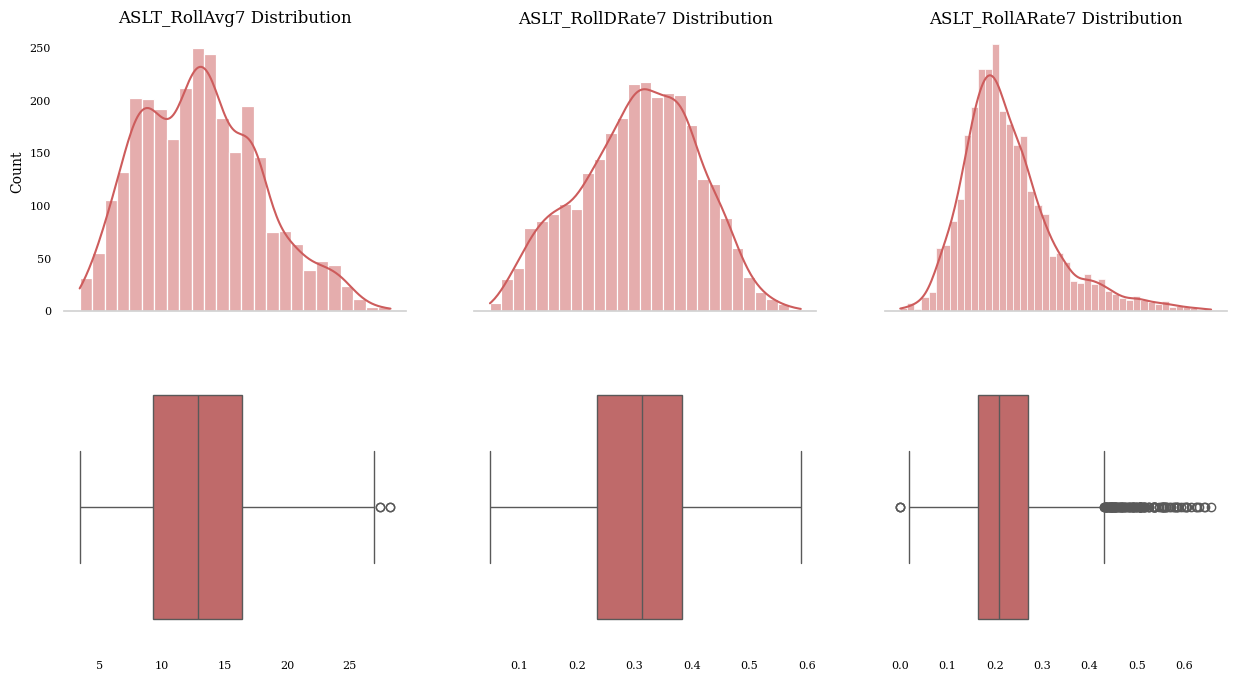

In [23]:
f.gen_paired_hist_box(
    features_oot[[
        f'{grp}_RollAvg7',
        f'{grp}_RollDRate7',
        f'{grp}_RollARate7',
    ]]
)

Regarding the cluster medians, we see no significant changes.

In [13]:
cluster_oot = oot_aslt.dropna().reset_index(drop=True).copy()

X_oot = scaler_aslt.transform(features_oot)

cluster_oot['cluster'] = [pc.cluster_mapping['ASLT'][x] for x in kmeans_aslt.predict(X_oot)]

cluster_oot[features_list + ['cluster']]\
    .groupby('cluster')\
    .agg(['median'])

,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgHardship7
,median,median,median,median
cluster,,,,
0,10.285714,0.168504,0.246344,10.134419
1,8.285714,0.281689,0.157143,31.162302
2,14.857143,0.337636,0.272260,73.000000
3,17.000000,0.390854,0.170928,60.994851


The transition matrix, by its turn, shows a slight shift for some values. In particular, of greater significance, there is no jump between clusters 0 and 3, since $T_{03} = T_{30} = 0$, $T_{32}$ has doubled, and the stability of the clusters is preserved.

In [14]:
f.get_transition_matrix(cluster_oot)

next_cluster,0,1,2,3
cluster,,,,
0,0.888016,0.110020,0.001965,0.000000
1,0.070496,0.908616,0.014360,0.006527
2,0.001961,0.008824,0.917647,0.071569
3,0.000000,0.017078,0.132827,0.850095


### Kullback-Leibler Divergence
The Kullback-Leibler Divergence (KLD) is a statistical measure used to quanify how one probability distribution differs from another. It tells us how much information is gained when the actual distribution of events deviates from a reference distribution.

In our context, the distribution will be evaluated on a weekly period, such that, each week the city has a certain proportion of districts assigned to each cluster. We then compare this weekly distribution to a baseline distribution, which refers to the historical pattern learned from the trained period (2022-2024). If the weekly distribution is similar to the baseline, the KLD is close to zero. If the distribution begins to shift, with more districts entering high-risk cluster, for example, the KLD increases, signaling the system is moving away from its historical state. It then provides a single continuous metric for detecting early signs of risk escalation, hence informing model retraining, that can be monitored over time.

Mathematically, it is given by the expression $$\text{KLD}(p||q) = \sum_x p_x \log\frac{p_x}{q_x},$$ where $p_x$ is a probability distribution over variable $x$ and $q_x$ is the baseline distribution, over the same variable.

In [ ]:
# we thus start by calculating the  baseline distribution
baseline_dist = cluster_aslt.groupby('cluster').size().div(len(cluster_aslt))
baseline_dist

cluster
0    0.164587
1    0.287026
2    0.219296
3    0.329091
dtype: float64

In [ ]:
# afterwards, we calculate the weekly distribution in the OOT period
cluster_oot['week'] = cluster_oot['date'].dt.to_period('W').dt.start_time

weekly_dist = (
    cluster_oot
    .groupby(['week', 'cluster'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .reset_index(level=0, drop=True)
    .to_frame(name='pct')
    .reset_index()
)
weekly_dist

,week,cluster,pct
0,2024-12-30,0,0.145455
1,2024-12-30,1,0.272727
2,2024-12-30,2,0.327273
3,2024-12-30,3,0.254545
4,2025-01-06,0,0.162338
...,...,...,...
71,2025-04-28,3,0.240260
72,2025-05-05,0,0.094828
73,2025-05-05,1,0.379310
74,2025-05-05,2,0.258621


In [17]:
q = baseline_dist.values

kld_records = []
for w in weekly_dist['week'].unique():
    dist_w = weekly_dist.query('week == @w').set_index('cluster')['pct']
    p = dist_w.reindex(baseline_dist.index, fill_value=0).values

    kld_records.append({'week': w, 'kld': f.kld(p, q)})

df_kld = pd.DataFrame(kld_records)
df_kld

,week,kld
0,2024-12-30,0.033738
1,2025-01-06,0.122771
2,2025-01-13,0.093966
3,2025-01-20,0.191407
4,2025-01-27,0.180617
5,2025-02-03,0.140227
6,2025-02-10,0.169004
7,2025-02-17,0.149978
8,2025-02-24,0.163862
9,2025-03-03,0.096340


We observe values greater than 0.10 at the start of 2025 from the 3 week moving average of the KLD below. As highlighted in the 02 Notebook, the start of every year is a notorious time period, with a greater frequency of occurrences. As they refer to outliers regarding a date point of view, it is expected to see a higher KLD.

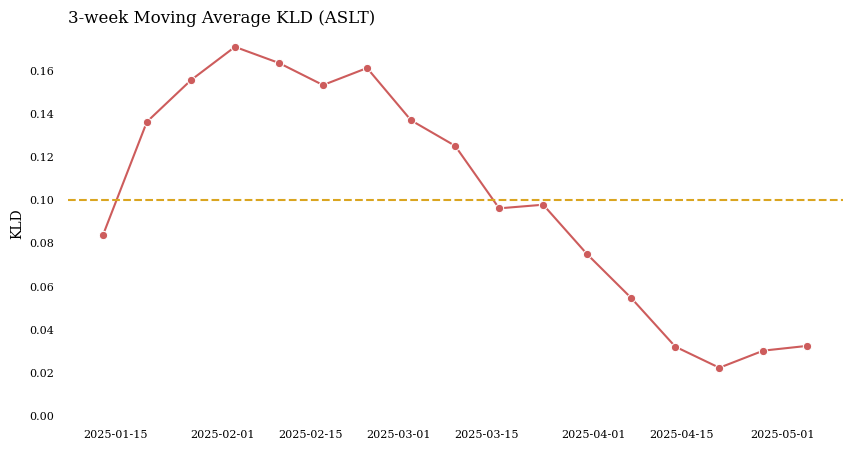

In [28]:
sns.lineplot(
    data=df_kld.set_index('week').rolling(3).mean(),
    x='week',
    y='kld',
    marker='o',
    color=colors['ASLT']
)
plt.title('3-week Moving Average KLD (ASLT)', loc='left')
plt.axhline(y=0.1, color='goldenrod', linestyle='--')
plt.ylim(0)
plt.ylabel('KLD')
plt.xlabel('')
plt.box(False)